In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("data/wine_data.csv",header=None,usecols=[0,1,2])
df.columns=["Class label", "Alcohol", "Malic acid"]

In [5]:
df.head()

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


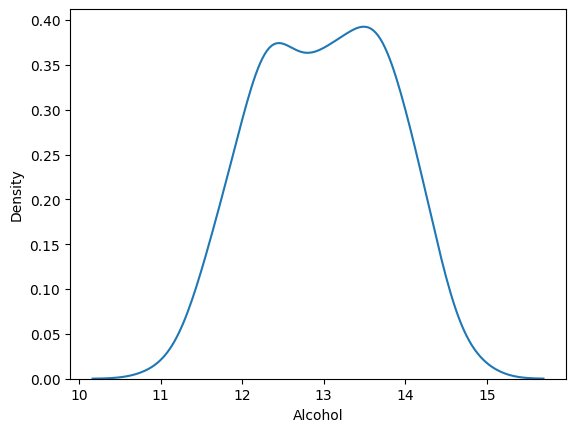

In [7]:
sns.kdeplot(df["Alcohol"])
plt.show()

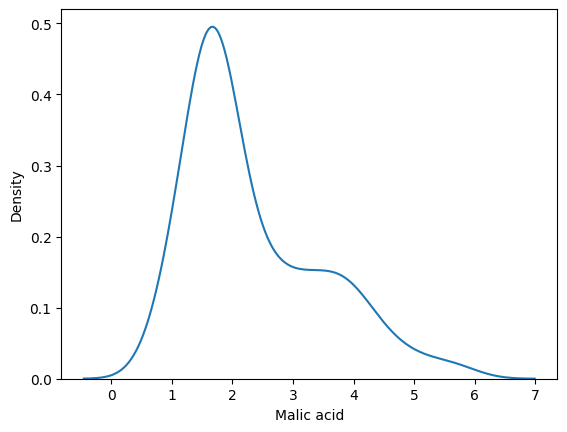

In [8]:
sns.kdeplot(df["Malic acid"])
plt.show()

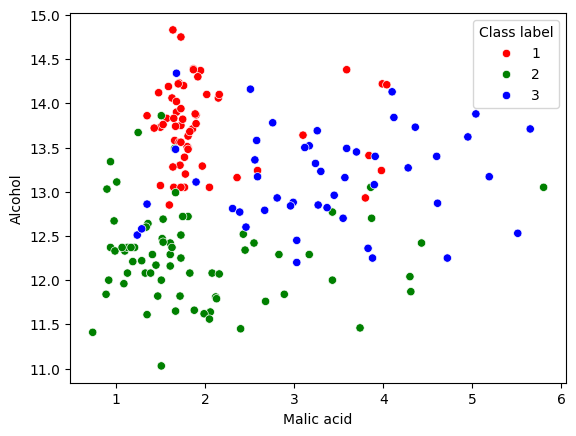

In [11]:
sns.scatterplot(x = df["Malic acid"], y = df["Alcohol"], hue = df["Class label"], palette = ["red", "green", "blue"])
plt.show()

In [13]:
X = df.iloc[:, 1:3]
X

,Alcohol,Malic acid
0,14.23,1.71
1,13.20,1.78
2,13.16,2.36
3,14.37,1.95
4,13.24,2.59
...,...,...
173,13.71,5.65
174,13.40,3.91
175,13.27,4.28
176,13.17,2.59


In [15]:
y = df.iloc[:, 0]
y

0      1
1      1
2      1
3      1
4      1
      ..
173    3
174    3
175    3
176    3
177    3
Name: Class label, Length: 178, dtype: int64

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

X_train.shape, y_train.shape

((142, 2), (142,))

In [17]:
# Standardization

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X_train) #fit on training data, it will first calculate parameters

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [21]:
X_train_scaled.head()

,Alcohol,Malic acid
0,0.255263,0.124490
1,0.444737,0.185714
2,0.276316,0.100000
3,0.807895,0.228571
4,0.713158,0.157143


In [22]:
np.round(X_train_scaled.describe(), 1)

,Alcohol,Malic acid
count,142.0,142.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.3,0.1
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


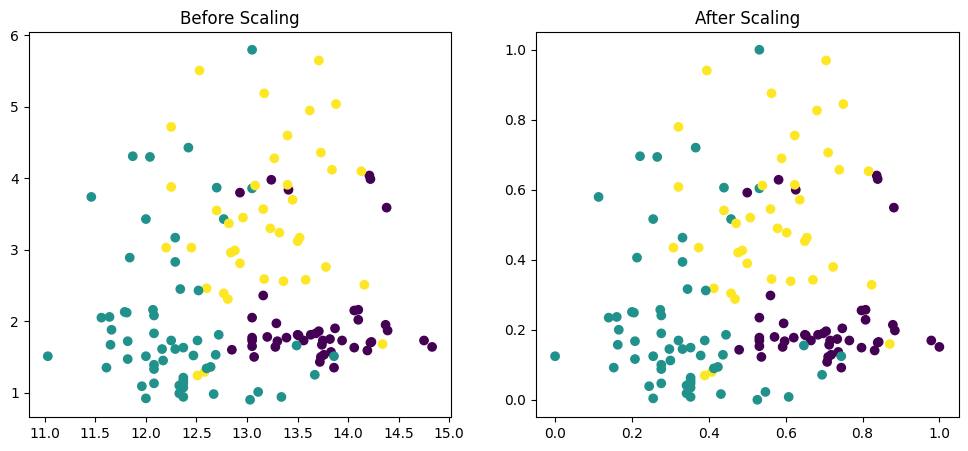

In [25]:
plt.figure(figsize=(12, 5))

# Before Scaling
plt.subplot(1, 2, 1)
plt.scatter(X_train['Alcohol'], X_train['Malic acid'], c=y_train)
plt.title("Before Scaling")

# After Scaling
plt.subplot(1, 2, 2)
plt.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'], c=y_train)
plt.title("After Scaling")

plt.show()
